In [1]:
import sys
!{sys.executable} -m pip install cfgrib eccodes
!{sys.executable} -m pip install windrose

In [2]:
import xarray as xr
print(xr.backends.list_engines())

{'netcdf4': <NetCDF4BackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html, 'scipy': <ScipyBackendEntrypoint>
  Open netCDF files (.nc, .nc4, .cdf and .gz) using scipy in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html, 'cfgrib': <CfGribBackend>
  Open GRIB files (.grib, .grib2, .grb and .grb2) in Xarray
  Learn more at https://github.com/ecmwf/cfgrib, 'gini': <GiniXarrayBackend>, 'store': <StoreBackendEntrypoint>
  Open AbstractDataStore instances in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}


In [3]:
import cfgrib
import os

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

files = [f for f in os.listdir(data_dir) if f.endswith('.grib')]
print(f"Total GRIB files: {len(files)}")
print()

for f in files:
    full_path = os.path.join(data_dir, f)
    datasets = cfgrib.open_datasets(full_path)
    for i, ds in enumerate(datasets):
        print(f"{f[:20]}...")
        print(f"  Variables: {list(ds.data_vars)}")
        print(f"  Time: {str(ds.time.values[0])[:10]} to {str(ds.time.values[-1])[:10]}")
        print(f"  Length: {len(ds.time.values)}")
    print()

Total GRIB files: 4

4442e4d799f439dfe045...
  Variables: ['u100', 'v100']
  Time: 2010-01-01 to 2020-12-31
  Length: 32144

5996358addf110711f83...
  Variables: ['mwd']
  Time: 2010-01-01 to 2020-12-31
  Length: 32144

87651c937f5a950f80d1...
  Variables: ['swh', 'pp1d']
  Time: 2010-01-01 to 2020-12-31
  Length: 32144

98aa70fc79993ea5c3b6...
  Variables: ['u10', 'v10']
  Time: 2010-01-01 to 2020-12-31
  Length: 32144



In [4]:
import cfgrib
import numpy as np

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

site_lat = 37.74838
site_lon = -9.01453

#File names
file_10m  = '98aa70fc79993ea5c3b6c54879df5625.grib' 
file_100m = '4442e4d799f439dfe0452da8fb8de243.grib'
file_wave = '87651c937f5a950f80d1c4291b8e5ed5.grib'

#Load datasets 
ds_10m  = cfgrib.open_datasets(data_dir + '\\' + file_10m)[0]
ds_100m = cfgrib.open_datasets(data_dir + '\\' + file_100m)[0]
ds_wave = cfgrib.open_datasets(data_dir + '\\' + file_wave)[0]

# Nearest point to Sines 
pt_10m  = ds_10m.sel(latitude=site_lat,  longitude=site_lon, method='nearest')
pt_100m = ds_100m.sel(latitude=site_lat, longitude=site_lon, method='nearest')
pt_wave = ds_wave.sel(latitude=site_lat, longitude=site_lon, method='nearest')

print(f"pt_10m:  {len(pt_10m.time.values)} records")
print(f"pt_100m: {len(pt_100m.time.values)} records")
print(f"pt_wave: {len(pt_wave.time.values)} records")

pt_10m:  32144 records
pt_100m: 32144 records
pt_wave: 32144 records


In [5]:
# Check time steps
import numpy as np

times_10m  = pt_10m.time.values
times_100m = pt_100m.time.values
times_wave = pt_wave.time.values

# Check interval between first few timestamps
dt_10m  = (times_10m[1]  - times_10m[0])  / np.timedelta64(1, 'h')
dt_100m = (times_100m[1] - times_100m[0]) / np.timedelta64(1, 'h')
dt_wave = (times_wave[1] - times_wave[0]) / np.timedelta64(1, 'h')

print(f"10m  time step: {dt_10m} hours")
print(f"100m time step: {dt_100m} hours")
print(f"wave time step: {dt_wave} hours")

10m  time step: 3.0 hours
100m time step: 3.0 hours
wave time step: 3.0 hours


In [6]:
import pandas as pd
import numpy as np
import os

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

# ── Wind DataFrame (all in one since timestamps match) ────────────
df_wind = pd.DataFrame({
    'wind_speed_10m_ms':  np.sqrt(pt_10m['u10'].values**2 + pt_10m['v10'].values**2),
    'wind_dir_10m_deg':   (270 - np.degrees(np.arctan2(pt_10m['v10'].values, pt_10m['u10'].values))) % 360,
    'wind_speed_100m_ms': np.sqrt(pt_100m['u100'].values**2 + pt_100m['v100'].values**2),
    'wind_dir_100m_deg':  (270 - np.degrees(np.arctan2(pt_100m['v100'].values, pt_100m['u100'].values))) % 360,
}, index=pd.DatetimeIndex(pt_100m.time.values))

# ── Wave DataFrame ────────────────────────────────────────────────
df_wave = pd.DataFrame({
    'Hs_m': pt_wave['swh'].values,
    'Tp_s': pt_wave['pp1d'].values,
}, index=pd.DatetimeIndex(pt_wave.time.values))

print(f"Wind records:   {len(df_wind)}")
print(f"Wave records:   {len(df_wave)}")
print(f"Missing values (wind): {df_wind.isna().sum().sum()}")
print(f"Missing values (wave): {df_wave.isna().sum().sum()}")

# ── Save CSVs ─────────────────────────────────────────────────────
df_wind.to_csv(os.path.join(data_dir, 'wind_data_sines_2010_2020.csv'))
df_wave.to_csv(os.path.join(data_dir, 'wave_data_sines_2010_2020.csv'))

print("\nWind sample:")
print(df_wind.head())
print("\nWave sample:")
print(df_wave.head())
print("\nCSVs saved!")

Wind records:   32144
Wave records:   32144
Missing values (wind): 0
Missing values (wave): 0

Wind sample:
                     wind_speed_10m_ms  wind_dir_10m_deg  wind_speed_100m_ms  \
2010-01-01 00:00:00          11.378973        274.830200           13.204857   
2010-01-01 03:00:00          12.063279        277.673767           14.090853   
2010-01-01 06:00:00          12.025712        283.169434           14.135208   
2010-01-01 09:00:00          11.216561        287.584412           13.078920   
2010-01-01 12:00:00           9.727643        286.973114           11.236833   

                     wind_dir_100m_deg  
2010-01-01 00:00:00         274.922241  
2010-01-01 03:00:00         277.744537  
2010-01-01 06:00:00         282.981934  
2010-01-01 09:00:00         287.573883  
2010-01-01 12:00:00         287.262848  

Wave sample:
                         Hs_m       Tp_s
2010-01-01 00:00:00  4.356820  11.297707
2010-01-01 03:00:00  4.161001  11.206398
2010-01-01 06:00:00  4.12316

In [7]:
import pandas as pd
import cfgrib
import os

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

site_lat = 37.74838

# Load wave direction file
wave_dir_file = os.path.join(data_dir, '5996358addf110711f83f302d0f8b1.grib')
ds_wavedir = cfgrib.open_datasets(wave_dir_file)[0]

# Only select latitude (longitude is already a single point at -9.0)
pt_wavedir = ds_wavedir.sel(latitude=site_lat, method='nearest')

print(f"Extracted at latitude: {float(pt_wavedir.latitude.values):.4f}")
print(f"Longitude: {float(ds_wavedir.longitude.values):.4f}")
print(f"Records: {len(pt_wavedir.time.values)}")
print(pt_wavedir['mwd'].values[:5])

# Build and save separate CSV
df_wavedir = pd.DataFrame({
    'wave_dir_deg': pt_wavedir['mwd'].values,
}, index=pd.DatetimeIndex(pt_wavedir.time.values))

wave_dir_csv = os.path.join(data_dir, 'wave_direction_sines_2010_2020.csv')
df_wavedir.to_csv(wave_dir_csv)

print(f"\nSample:")
print(df_wavedir.head())
print(f"\nWave direction CSV saved! ({len(df_wavedir)} records)")

Extracted at latitude: 37.5000
Longitude: -9.0000
Records: 32144
[286.52393 288.67395 290.76672 294.81274 301.3291 ]

Sample:
                     wave_dir_deg
2010-01-01 00:00:00    286.523926
2010-01-01 03:00:00    288.673950
2010-01-01 06:00:00    290.766724
2010-01-01 09:00:00    294.812744
2010-01-01 12:00:00    301.329102

Wave direction CSV saved! (32144 records)


In [8]:
import pandas as pd
import numpy as np

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

df_wind = pd.read_csv(data_dir + r'\wind_data_sines_2010_2020.csv', index_col=0, parse_dates=True)
df_wave = pd.read_csv(data_dir + r'\wave_data_sines_2010_2020.csv', index_col=0, parse_dates=True)
df_wavedir = pd.read_csv(data_dir + r'\wave_direction_sines_2010_2020.csv', index_col=0, parse_dates=True)

print("=== WIND AT 10m ===")
print(f"Mean speed:      {df_wind['wind_speed_10m_ms'].mean():.2f} m/s")
print(f"Std speed:       {df_wind['wind_speed_10m_ms'].std():.2f} m/s")
print(f"Min speed:       {df_wind['wind_speed_10m_ms'].min():.2f} m/s")
print(f"Max speed:       {df_wind['wind_speed_10m_ms'].max():.2f} m/s")

print("\n=== WIND AT 100m ===")
print(f"Mean speed:      {df_wind['wind_speed_100m_ms'].mean():.2f} m/s")
print(f"Std speed:       {df_wind['wind_speed_100m_ms'].std():.2f} m/s")
print(f"Min speed:       {df_wind['wind_speed_100m_ms'].min():.2f} m/s")
print(f"Max speed:       {df_wind['wind_speed_100m_ms'].max():.2f} m/s")

print("\n=== WAVE HEIGHT (Hs) ===")
print(f"Mean Hs:         {df_wave['Hs_m'].mean():.2f} m")
print(f"Std Hs:          {df_wave['Hs_m'].std():.2f} m")
print(f"Min Hs:          {df_wave['Hs_m'].min():.2f} m")
print(f"Max Hs:          {df_wave['Hs_m'].max():.2f} m")

print("\n=== WAVE PERIOD (Tp) ===")
print(f"Mean Tp:         {df_wave['Tp_s'].mean():.2f} s")
print(f"Std Tp:          {df_wave['Tp_s'].std():.2f} s")
print(f"Min Tp:          {df_wave['Tp_s'].min():.2f} s")
print(f"Max Tp:          {df_wave['Tp_s'].max():.2f} s")

print("\n=== WAVE DIRECTION (mwd) ===")
print(f"Mean direction:  {df_wavedir['wave_dir_deg'].mean():.1f} °")
print(f"Std direction:   {df_wavedir['wave_dir_deg'].std():.1f} °")
print(f"Min direction:   {df_wavedir['wave_dir_deg'].min():.1f} °")
print(f"Max direction:   {df_wavedir['wave_dir_deg'].max():.1f} °")

# Dominant direction sector for both wind and waves
bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

df_wind['wind_sector'] = pd.cut(df_wind['wind_dir_10m_deg'], bins=bins, labels=labels)
df_wavedir['wave_sector'] = pd.cut(df_wavedir['wave_dir_deg'], bins=bins, labels=labels)

print(f"\nDominant wind direction:  {df_wind['wind_sector'].value_counts().idxmax()}")
print(f"Dominant wave direction:  {df_wavedir['wave_sector'].value_counts().idxmax()}")

print("\n=== WIND DIRECTION BREAKDOWN ===")
print(df_wind['wind_sector'].value_counts().sort_index())

print("\n=== WAVE DIRECTION BREAKDOWN ===")
print(df_wavedir['wave_sector'].value_counts().sort_index())

=== WIND AT 10m ===
Mean speed:      5.87 m/s
Std speed:       2.70 m/s
Min speed:       0.02 m/s
Max speed:       18.54 m/s

=== WIND AT 100m ===
Mean speed:      7.29 m/s
Std speed:       3.46 m/s
Min speed:       0.01 m/s
Max speed:       23.39 m/s

=== WAVE HEIGHT (Hs) ===
Mean Hs:         1.96 m
Std Hs:          0.90 m
Min Hs:          0.47 m
Max Hs:          7.75 m

=== WAVE PERIOD (Tp) ===
Mean Tp:         11.20 s
Std Tp:          2.70 s
Min Tp:          3.23 s
Max Tp:          21.39 s

=== WAVE DIRECTION (mwd) ===
Mean direction:  306.4 °
Std direction:   30.6 °
Min direction:   0.1 °
Max direction:   360.0 °

Dominant wind direction:  NW
Dominant wave direction:  W

=== WIND DIRECTION BREAKDOWN ===
wind_sector
N      5067
NE     2216
E      1323
SE     1576
S      2500
SW     2570
W      4411
NW    12481
Name: count, dtype: int64

=== WAVE DIRECTION BREAKDOWN ===
wave_sector
N        91
NE       47
E        93
SE       92
S       174
SW     1590
W     15655
NW    14402
Name: c

C:\Users\Carolina\AppData\Local\Temp\ipykernel_9872\388691186.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


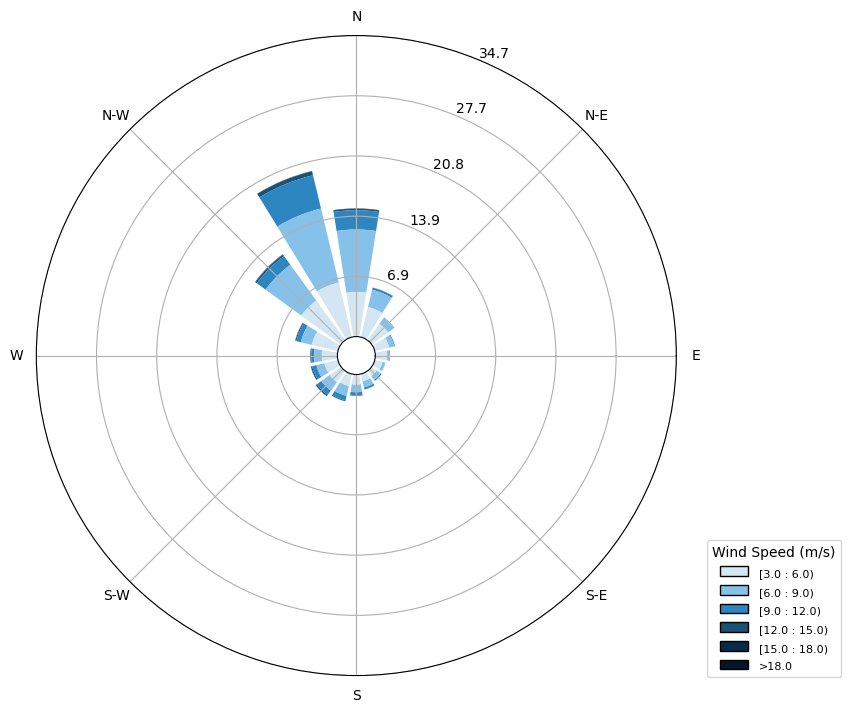

In [9]:
import matplotlib.pyplot as plt
from windrose import WindroseAxes

data_fig_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data\figures'

df_wind = pd.read_csv(data_dir + r'\wind_data_sines_2010_2020.csv', index_col=0, parse_dates=True)

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

ax.bar(df_wind['wind_dir_10m_deg'], 
       df_wind['wind_speed_10m_ms'], 
       normed=True, 
       bins=[3,6,9,12,15,18],
       calm_limit=3,
        colors=['#d4e6f1','#85c1e9','#2e86c1','#1a5276','#0b2a4a','#061626'],
       nsector=16,       linewidth=0.5)

ax.set_legend(title='Wind Speed (m/s)', 
              loc='lower left', 
              bbox_to_anchor=(1.05, 0),
              fontsize=10)
#ax.set_title('Wind Rose at 10 m (2010-2020)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'wind_rose_10m.png'), dpi=300, bbox_inches='tight')
plt.show()


predoinant in NNW 
secondary sector from NNE
light contributions spread across other directions


C:\Users\Carolina\AppData\Local\Temp\ipykernel_9872\3345220765.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


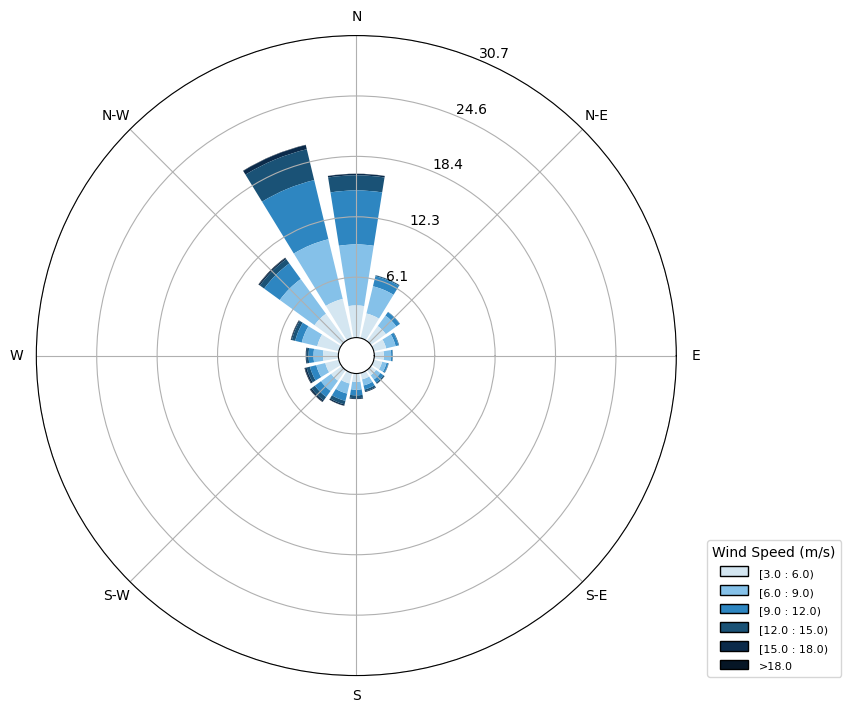

In [19]:
data_fig_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data\figures'

df_wind = pd.read_csv(data_dir + r'\wind_data_sines_2010_2020.csv', index_col=0, parse_dates=True)

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

ax.bar(df_wind['wind_dir_100m_deg'], 
       df_wind['wind_speed_100m_ms'], 
       normed=True, 
       bins=[3,6,9,12,15,18],
       calm_limit=3,
        colors=['#d4e6f1','#85c1e9','#2e86c1','#1a5276','#0b2a4a','#061626'],
       nsector=16,       linewidth=0.5)

ax.set_legend(title='Wind Speed (m/s)', 
              loc='lower left', 
              bbox_to_anchor=(1.05, 0),
              fontsize=10)
#ax.set_title('Wind Rose at 100 m (2010-2020)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'wind_rose_100m.png'), dpi=300, bbox_inches='tight')
plt.show()


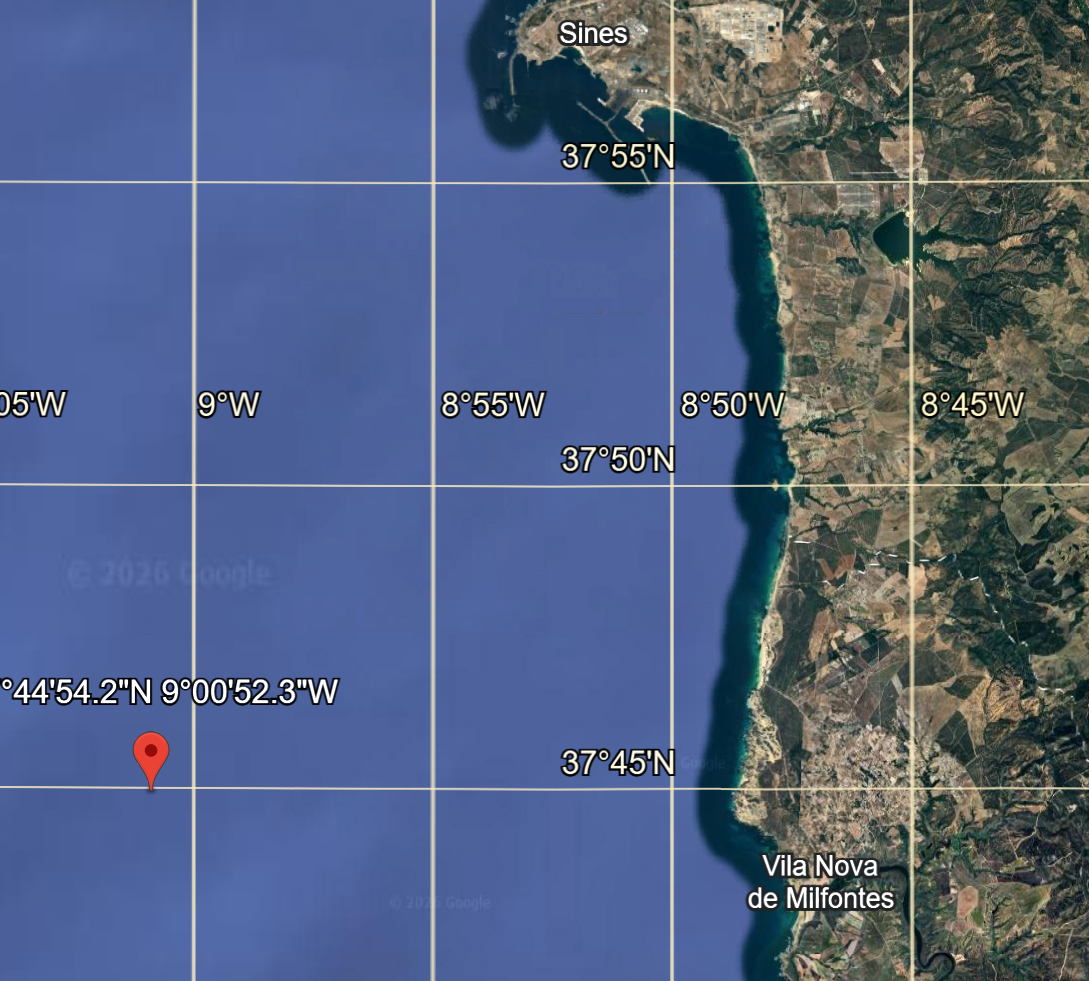

very similar to wind rose for Vila Nova de Mil Fontes
note that in Sines city, the wave direction is different. however, the site is more to the south and west, therefore it is different!!   
if we google sines: for the best surfing conditions in Sines, Portugal, the ideal swell (wave) direction is West to Southwest  
if we google Vila Nova de Milfontes (the closest city if we draw a horizontal line, see map): The typical and ideal wave (swell) direction is Northwest (NW)


reaches speeds larger than 15m/s  
more concentrated around N  


In [11]:
#m/s to km/h
v3= 3*3.6
print(f"3 m/s = {v3:.1f} km/h")
v6= 6*3.6
print(f"6 m/s = {v6:.1f} km/h")
v9= 9*3.6
print(f"9 m/s = {v9:.1f} km/h")
v12= 12*3.6
print(f"12 m/s = {v12:.1f} km/h")
v15= 15*3.6    
print(f"15 m/s = {v15:.1f} km/h")
v18= 18*3.6
print(f"18 m/s = {v18:.1f} km/h")

3 m/s = 10.8 km/h
6 m/s = 21.6 km/h
9 m/s = 32.4 km/h
12 m/s = 43.2 km/h
15 m/s = 54.0 km/h
18 m/s = 64.8 km/h


                         Hs_m       Tp_s
2010-01-01 00:00:00  4.356820  11.297707
2010-01-01 03:00:00  4.161001  11.206398
2010-01-01 06:00:00  4.123161  11.046730
2010-01-01 09:00:00  4.093586  11.074074
2010-01-01 12:00:00  4.266944  11.590187

Total records: 32144
Time range: 2010-01-01 00:00:00 to 2020-12-31 21:00:00


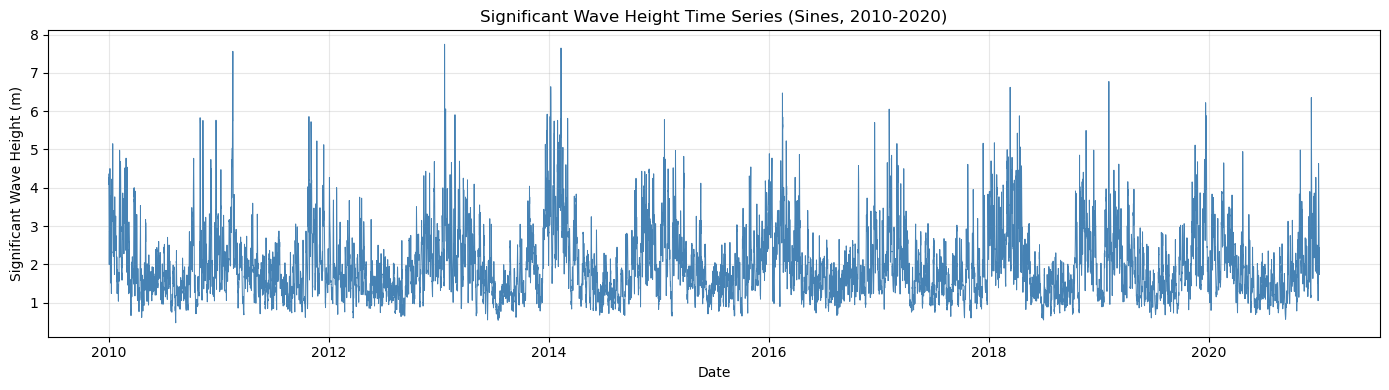

In [12]:
#time series Hs

#load wave data


df_wave = pd.read_csv(data_dir + r'\wave_data_sines_2010_2020.csv', index_col=0, parse_dates=True)

print(df_wave.head())
print(f"\nTotal records: {len(df_wave)}")
print(f"Time range: {df_wave.index[0]} to {df_wave.index[-1]}")

plt.figure(figsize=(14, 4))
plt.plot(df_wave.index, df_wave['Hs_m'], color='steelblue', linewidth=0.7) 
plt.xlabel('Date')
plt.ylabel('Significant Wave Height (m)')
plt.title('Significant Wave Height Time Series (Sines, 2010-2020)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'hs_timeseries.png'), dpi=300, bbox_inches='tight')
plt.show()


C:\Users\Carolina\AppData\Local\Temp\ipykernel_9872\4262309197.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


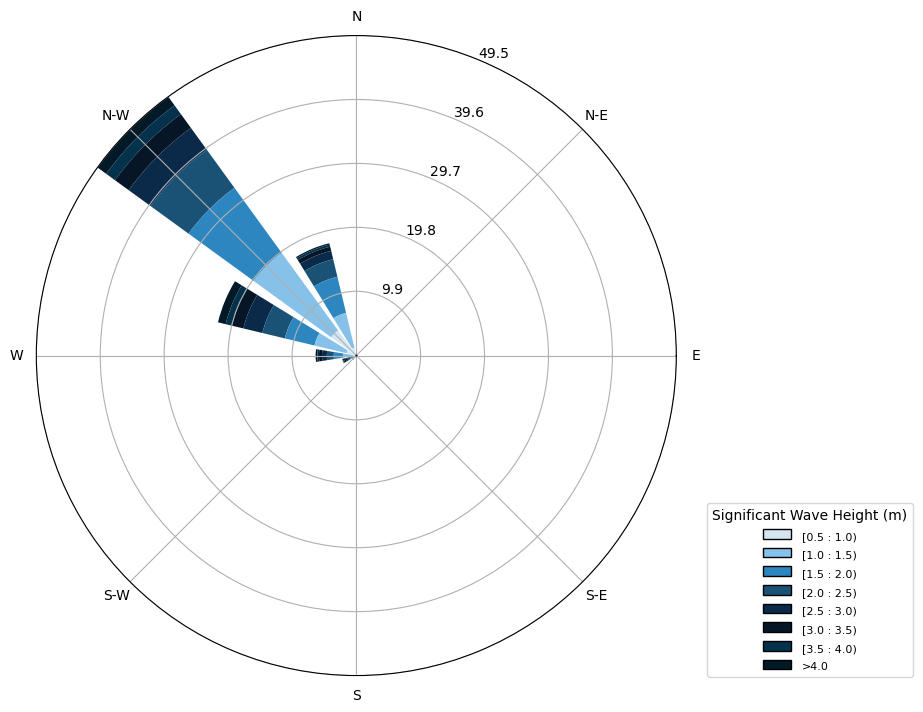

In [20]:
# wave direction rose

df_wavedir = pd.read_csv(data_dir + r'\wave_direction_sines_2010_2020.csv', index_col=0, parse_dates=True)

df_combined = df_wave.join(df_wavedir, how='inner')

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)
ax.bar(df_combined['wave_dir_deg'], 
       df_combined['Hs_m'], 
       normed=True, 
       bins=[0.5,1,1.5,2,2.5,3,3.5,4],
       calm_limit=0.5,
       colors=['#d4e6f1','#85c1e9','#2e86c1','#1a5276','#0b2a4a','#061626','#04314c','#021927'],
       nsector=16, linewidth=0.5)
ax.set_legend(title='Significant Wave Height (m)', 
              loc='lower left', 
              bbox_to_anchor=(1.05, 0),
              fontsize=10)
#ax.set_title('Wave Direction Rose (Sines, 2010-2020)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'wave_direction_rose.png'), dpi=300, bbox_inches='tight')
plt.show()

atlantic swell coming  from the northwest  
largest waves in NW sector   


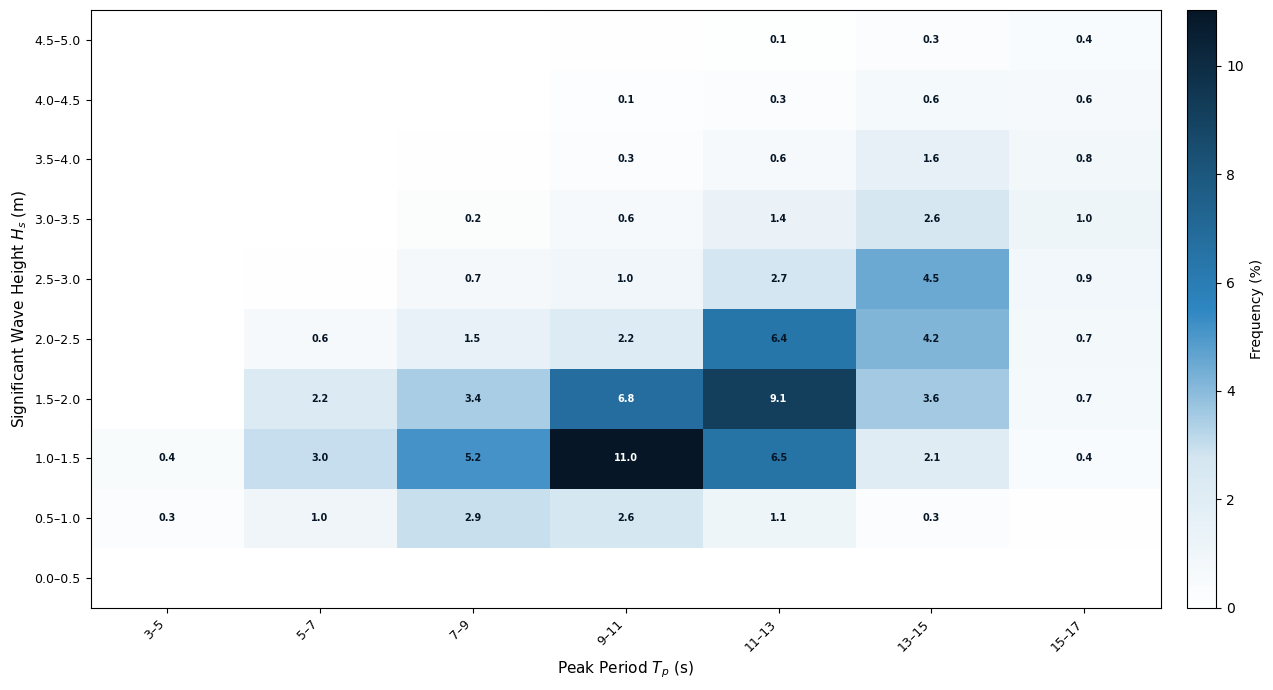

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df_wave = pd.read_csv(data_dir + r'\wave_data_sines_2010_2020.csv', index_col=0, parse_dates=True)

# Bin edges
hs_bins = np.arange(0, 5.5, 0.5)
tp_bins = np.arange(3, 19, 2)
hs_labels = [f"{b:.1f}–{b+0.5:.1f}" for b in hs_bins[:-1]]
tp_labels  = [f"{int(b)}–{int(b+2)}" for b in tp_bins[:-1]]

# Joint frequency count
scatter, _, _ = np.histogram2d(df_wave['Hs_m'], df_wave['Tp_s'],
                               bins=[hs_bins, tp_bins])
scatter_pct = scatter / scatter.sum() * 100

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
cmap = mcolors.LinearSegmentedColormap.from_list(
    "wave", ["#ffffff", "#d4e6f1", "#2e86c1", "#1a5276", "#061626"])

im = ax.imshow(scatter_pct, aspect="auto", origin="lower",
               cmap=cmap, vmin=0, vmax=scatter_pct.max())

for i in range(scatter_pct.shape[0]):
    for j in range(scatter_pct.shape[1]):
        val = scatter_pct[i, j]
        if val > 0.1:
            c = "white" if val > scatter_pct.max() * 0.6 else "#061626"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                    fontsize=7, color=c, fontweight="bold")

ax.set_xticks(range(len(tp_labels)))
ax.set_xticklabels(tp_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(hs_labels)))
ax.set_yticklabels(hs_labels, fontsize=9)
ax.set_xlabel("Peak Period $T_p$ (s)", fontsize=11)
ax.set_ylabel("Significant Wave Height $H_s$ (m)", fontsize=11)
#ax.set_title("$H_s$–$T_p$ Scatter Table – Sines (2010–2020)",
#             fontsize=13, pad=12)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Frequency (%)", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'hs_tp_scatter_table.png'), dpi=300, bbox_inches='tight')
plt.show()

In [15]:
11+9.1+6.5

26.6

most common state: Hs=1.0-1.5m, Tp=9-11s with 11%

the diagonal is expcted: bigger waves take longer to develop --> higher Hs higher Tp  
The upper right corner ($H_s$ > 3.5m, $T_p$ > 13s) has small values and are the winter storm sea states, which are rare but important for the extreme value analysis. 
cluster sits at Tp=9-13s even for small Hs confirms the site is swell dominated

references: 
\cite{holthuijsen2007
\cite{portilla2009}

bib file: 

@book{holthuijsen2007,
  author    = {Holthuijsen, Leo H.},
  title     = {Waves in Oceanic and Coastal Waters},
  publisher = {Cambridge University Press},
  year      = {2007}
}

@article{portilla2009,
  author  = {Portilla, Jes\'{u}s and Ocampo-Torres, Francisco J. and Monbaliu, Jaak},
  title   = {Spectral Partitioning and Identification of Wind Sea and Swell},
  journal = {Journal of Atmospheric and Oceanic Technology},
  volume  = {26},
  number  = {1},
  pages   = {107--122},
  year    = {2009}
}

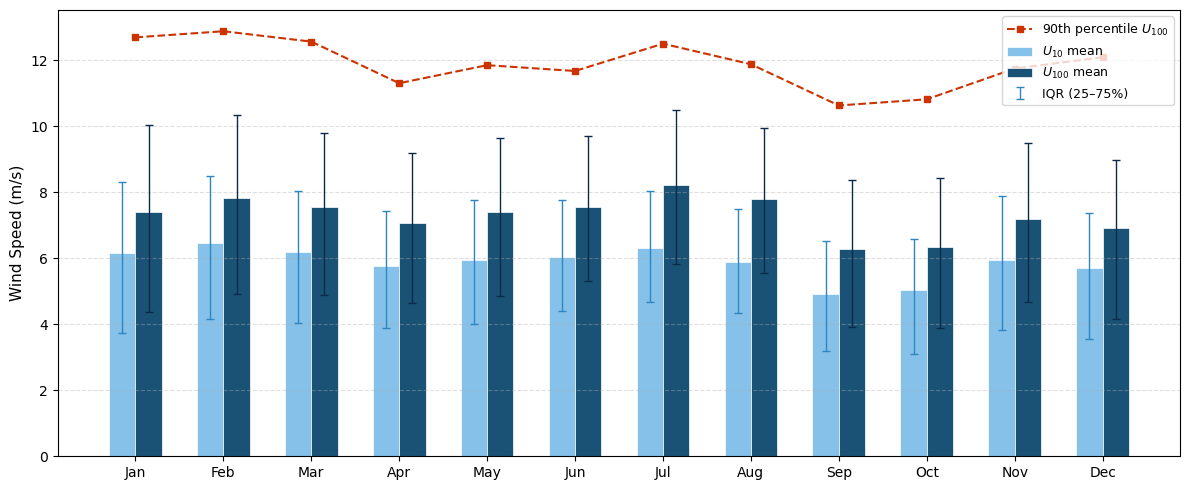

In [22]:
df_wind = pd.read_csv(data_dir + r'\wind_data_sines_2010_2020.csv', index_col=0, parse_dates=True)
df_wave = pd.read_csv(data_dir + r'\wave_data_sines_2010_2020.csv', index_col=0, parse_dates=True)

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
x = np.arange(12)
width = 0.6

# Monthly stats
def monthly_stats(series):
    g = series.groupby(series.index.month)
    return g.mean(), g.quantile(0.25), g.quantile(0.75), g.quantile(0.90)

u10_mean, u10_p25, u10_p75, u10_p90       = monthly_stats(df_wind['wind_speed_10m_ms'])
u100_mean, u100_p25, u100_p75, u100_p90    = monthly_stats(df_wind['wind_speed_100m_ms'])
hs_mean, hs_p25, hs_p75, hs_p90     = monthly_stats(df_wave['Hs_m'])

fig, ax = plt.subplots(figsize=(12, 5))
#ax.set_title("Monthly Wind Speed Variability - Sines (2010-2020)", fontsize=13)

ax.bar(x - width/4, u10_mean,  width/2, label='$U_{10}$ mean',
       color='#85c1e9', edgecolor='white', linewidth=0.5)
ax.bar(x + width/4, u100_mean, width/2, label='$U_{100}$ mean',
       color='#1a5276', edgecolor='white', linewidth=0.5)
ax.errorbar(x - width/4, u10_mean,
            yerr=[u10_mean - u10_p25, u10_p75 - u10_mean],
            fmt='none', color='#2e86c1', capsize=3, linewidth=1, label='IQR (25–75%)')
ax.errorbar(x + width/4, u100_mean,
            yerr=[u100_mean - u100_p25, u100_p75 - u100_mean],
            fmt='none', color='#0b2a4a', capsize=3, linewidth=1)
ax.plot(x, u100_p90, 's--', color='#cc3300', markersize=4,
        linewidth=1.5, label='90th percentile $U_{100}$')

ax.set_ylabel("Wind Speed (m/s)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'monthly_wind.png'), dpi=300, bbox_inches='tight')
plt.show()

"The wind at Sines genuinely does not follow a strong winter/summer pattern the way waves do, and this is physically real for the Portuguese coast. "  
July is the windiest month (~8.1m/s at 100m ) due to intensified summer trade winds --> Iberian thermal low eeffect 
https://upcommons.upc.edu/server/api/core/bitstreams/ea625566-f9e1-4cc0-8d4b-6b9a066d3f8e/content


The interquartile range shows how variable the conditions are wwithin each month  
90th percentile shows how intense/bad the conditions are on a bad day in that month 


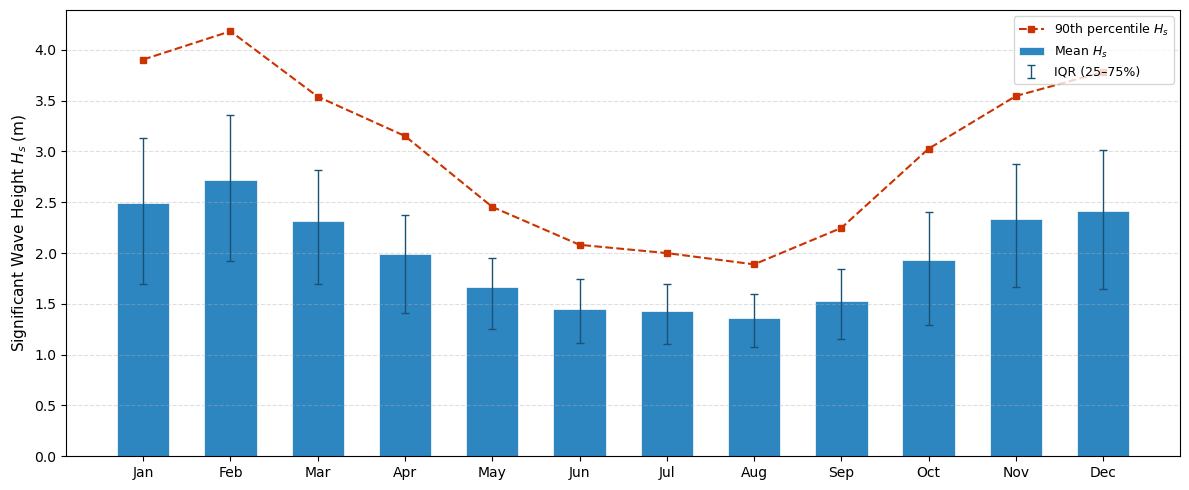

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
#ax.set_title("Monthly Wave Height Variability - Sines (2010-2020)", fontsize=13)

ax.bar(x, hs_mean, width, label='Mean $H_s$',
       color='#2e86c1', edgecolor='white', linewidth=0.5)
ax.errorbar(x, hs_mean,
            yerr=[hs_mean - hs_p25, hs_p75 - hs_mean],
            fmt='none', color='#1a5276', capsize=3, linewidth=1, label='IQR (25–75%)')
ax.plot(x, hs_p90, 's--', color='#cc3300', markersize=4,
        linewidth=1.5, label='90th percentile $H_s$')

ax.set_ylabel("Significant Wave Height $H_s$ (m)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'monthly_wave.png'), dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# print monthly IQR to verify

print(df_wind.groupby(df_wind.index.month)['wind_speed_100m_ms'].quantile([0.25, 0.75]).unstack())

        0.25       0.75
1   4.375720  10.053382
2   4.905420  10.341885
3   4.898231   9.792535
4   4.632664   9.192451
5   4.870112   9.652538
6   5.325116   9.717214
7   5.832805  10.497723
8   5.567456   9.934259
9   3.931526   8.365056
10  3.875859   8.419386
11  4.662753   9.491055
12  4.159862   8.982811
